# Chargement fichier client

In [10]:
#Bibliothèques
import sqlite3
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt, gc
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, pairwise_distances_argmin
from sklearn.cluster import AgglomerativeClustering





In [11]:
DB_PATH = Path(r"C:\Users\lza\Documents\P04_Segmenter_Clients_E-Commerce\olist.db")
if not DB_PATH.exists():
    raise FileNotFoundError(f"DB introuvable : {DB_PATH}")

df_rfm = pd.read_csv("./exports/clients_features_raw.csv")
print(df_rfm.shape)
df_rfm.head()

(93358, 4)


,customer_unique_id,recency,frequency,monetary
0,0a0a92112bd4c708ca5fde585afaa872,334,1,13664.08
1,da122df9eeddfedc1dc1f5349a1a690c,515,2,7571.63
2,763c8b1c9c68a0229c42c9fc6f662b93,45,1,7274.88
3,dc4802a71eae9be1dd28f5d788ceb526,563,1,6929.31
4,459bef486812aa25204be022145caa62,35,1,6922.21


# Préparation X + scaling

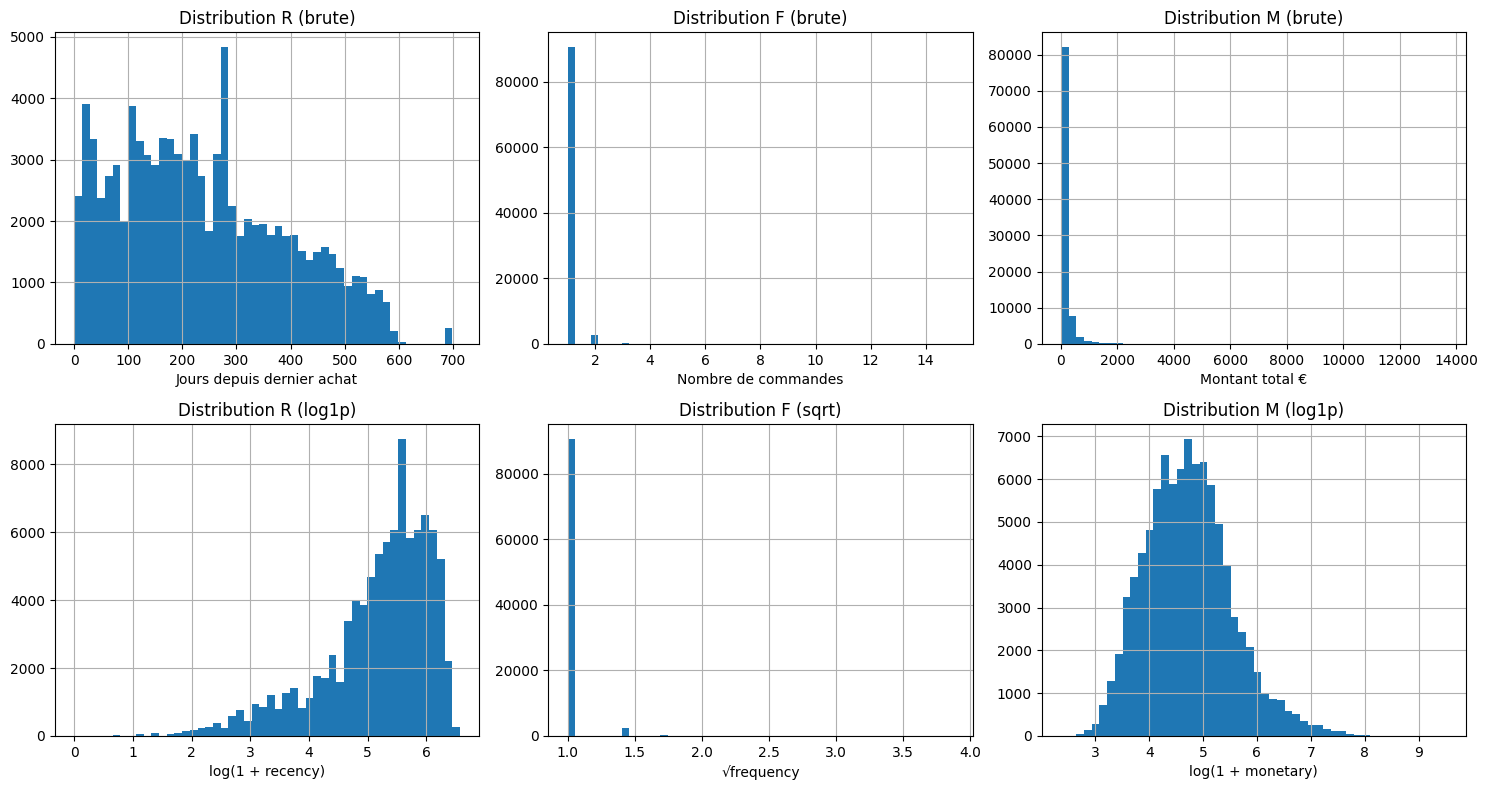

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# DISTRIBUTIONS ORIGINALES

df_rfm['recency'].hist(bins=50, ax=axes[0, 0])
axes[0, 0].set_title('Distribution R (brute)')
axes[0, 0].set_xlabel('Jours depuis dernier achat')

df_rfm['frequency'].hist(bins=50, ax=axes[0, 1])
axes[0, 1].set_title('Distribution F (brute)')
axes[0, 1].set_xlabel('Nombre de commandes')

df_rfm['monetary'].hist(bins=50, ax=axes[0, 2])
axes[0, 2].set_title('Distribution M (brute)')
axes[0, 2].set_xlabel('Montant total €')

# TRANSFORMATIONS

R_transformed = np.log1p(df_rfm['recency']) 
F_transformed = np.sqrt(df_rfm['frequency'])
M_transformed = np.log1p(df_rfm['monetary'])


# DISTRIBUTIONS TRANSFORMÉES 

R_transformed.hist(bins=50, ax=axes[1, 0])
axes[1, 0].set_title('Distribution R (log1p)')
axes[1, 0].set_xlabel('log(1 + recency)')

F_transformed.hist(bins=50, ax=axes[1, 1])
axes[1, 1].set_title('Distribution F (sqrt)')
axes[1, 1].set_xlabel('√frequency')

M_transformed.hist(bins=50, ax=axes[1, 2])
axes[1, 2].set_title('Distribution M (log1p)')
axes[1, 2].set_xlabel('log(1 + monetary)')

plt.tight_layout()
plt.show()


# Standardisation pour le clustering

X = np.column_stack([R_transformed, F_transformed, M_transformed])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)




# Clustering

# K-Means 

K-MEANS CLUSTERING
k=2 → silhouette=0.713, inertia=192019
k=3 → silhouette=0.421, inertia=131068
k=4 → silhouette=0.395, inertia=84731
k=5 → silhouette=0.359, inertia=70142
k=6 → silhouette=0.355, inertia=60249
k=7 → silhouette=0.354, inertia=53071
k=8 → silhouette=0.356, inertia=47363


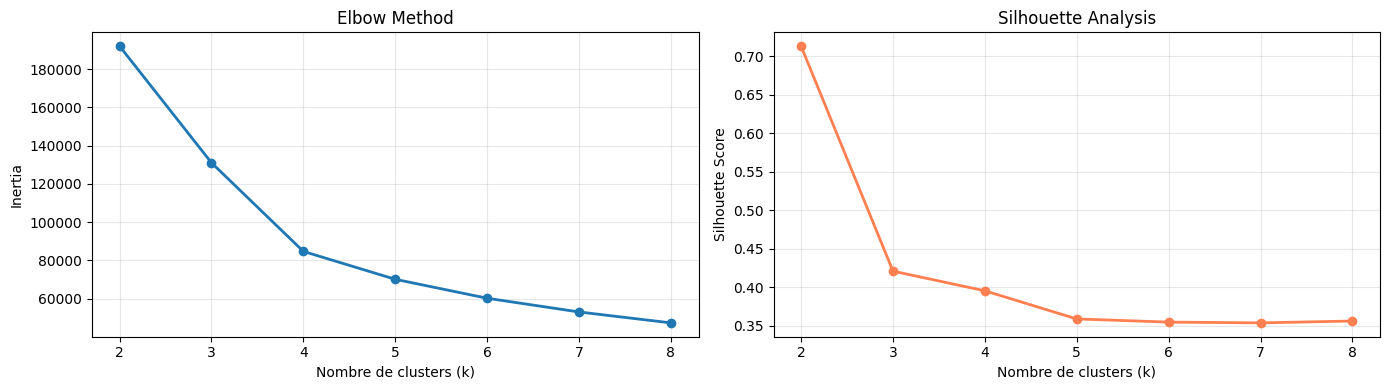


✓ K-Means appliqué avec k=4
cluster_kmeans
0    32201
1    42323
2    16033
3     2801
Name: count, dtype: int64


In [13]:
print("=" * 50)
print("K-MEANS CLUSTERING")
print("=" * 50)

# Tester plusieurs k
silhouette_scores = []
inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    silhouette = silhouette_score(X_scaled, labels)
    silhouette_scores.append(silhouette)
    inertias.append(km.inertia_)
    
    print(f"k={k} → silhouette={silhouette:.3f}, inertia={km.inertia_:.0f}")

# Visualiser elbow + silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(k_range, inertias, marker='o', linewidth=2)
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, marker='o', linewidth=2, color='coral')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Appliquer le meilleur k (ajuste selon les graphiques)
BEST_K = 4  # à ajuster
kmeans_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df_rfm['cluster_kmeans'] = kmeans_final.fit_predict(X_scaled)

print(f"\n✓ K-Means appliqué avec k={BEST_K}")
print(df_rfm['cluster_kmeans'].value_counts().sort_index())


DBSCAN CLUSTERING


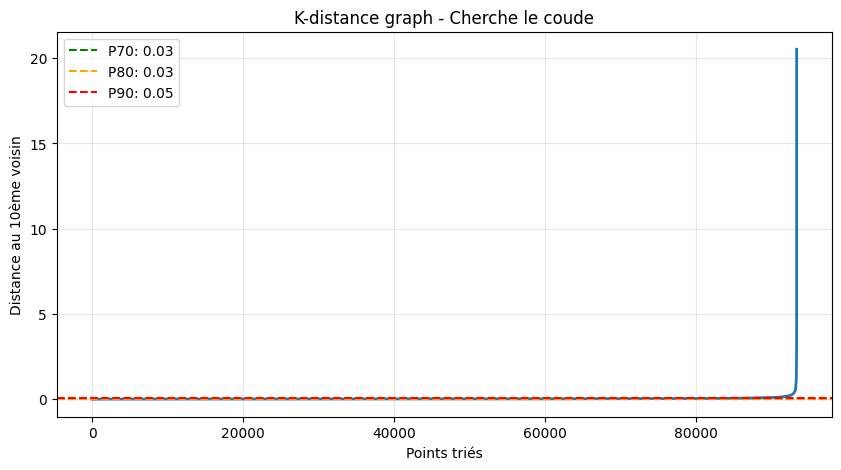


Test de différents epsilon :
eps=0.026 → 303 clusters | 21.4% bruit | silhouette=-0.394
eps=0.029 → 286 clusters | 17.6% bruit | silhouette=-0.354
eps=0.034 → 292 clusters | 13.7% bruit | silhouette=-0.361
eps=0.040 → 211 clusters | 10.1% bruit | silhouette=-0.369
eps=0.052 → 144 clusters | 6.9% bruit | silhouette=-0.337

 Pas de solution optimale, utilisation de eps=0.034

✓ DBSCAN appliqué : 292 clusters, 12,806 points de bruit (13.7%)

Distribution des clusters :
cluster_dbscan
-1      12806
 0         13
 1         15
 2         20
 3         23
        ...  
 287        8
 288       14
 289       11
 290       13
 291       12
Name: count, Length: 293, dtype: int64


KeyError: "Column(s) ['F', 'M', 'R'] do not exist"

In [16]:

# CLUSTERING DBSCAN

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

print("\n" + "=" * 70)
print("DBSCAN CLUSTERING")
print("=" * 70)

# Trouver epsilon optimal
MIN_SAMPLES = 10

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES + 1, metric="euclidean").fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

# Visualiser k-distance pour choisir epsilon
plt.figure(figsize=(10, 5))
plt.plot(k_distances, linewidth=2)
plt.axhline(y=np.percentile(k_distances, 70), color='g', linestyle='--', 
            label=f'P70: {np.percentile(k_distances, 70):.2f}')
plt.axhline(y=np.percentile(k_distances, 80), color='orange', linestyle='--', 
            label=f'P80: {np.percentile(k_distances, 80):.2f}')
plt.axhline(y=np.percentile(k_distances, 90), color='r', linestyle='--', 
            label=f'P90: {np.percentile(k_distances, 90):.2f}')
plt.xlabel('Points triés')
plt.ylabel(f'Distance au {MIN_SAMPLES}ème voisin')
plt.title('K-distance graph - Cherche le coude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Tester plusieurs epsilon
print("\nTest de différents epsilon :")
eps_tests = [
    np.percentile(k_distances, 70),
    np.percentile(k_distances, 75),
    np.percentile(k_distances, 80),
    np.percentile(k_distances, 85),
    np.percentile(k_distances, 90)
]

best_eps = None
best_score = -1
best_n_clusters = 0

for eps in eps_tests:
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    pct_noise = n_noise / len(labels) * 100
    
    # Calculer silhouette si possible
    mask = labels != -1
    if mask.sum() > 0 and n_clusters > 1:
        sil = silhouette_score(X_scaled[mask], labels[mask])
        sil_str = f"{sil:.3f}"
        
        # Garder le meilleur (3-8 clusters, <25% bruit)
        if 3 <= n_clusters <= 8 and pct_noise < 25 and sil > best_score:
            best_score = sil
            best_eps = eps
            best_n_clusters = n_clusters
    else:
        sil_str = "N/A"
    
    print(f"eps={eps:.3f} → {n_clusters} clusters | {pct_noise:.1f}% bruit | silhouette={sil_str}")

# Si pas de bon epsilon trouvé, prendre P80 par défaut
if best_eps is None:
    best_eps = np.percentile(k_distances, 80)
    print(f"\n Pas de solution optimale, utilisation de eps={best_eps:.3f}")
else:
    print(f"\n Meilleur epsilon : {best_eps:.3f} ({best_n_clusters} clusters)")

# Appliquer DBSCAN final
dbscan = DBSCAN(eps=best_eps, min_samples=MIN_SAMPLES)
df_rfm['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df_rfm['cluster_dbscan'])) - (1 if -1 in df_rfm['cluster_dbscan'].values else 0)
n_noise = (df_rfm['cluster_dbscan'] == -1).sum()
pct_noise = n_noise / len(df_rfm) * 100

print(f"\n✓ DBSCAN appliqué : {n_clusters_db} clusters, {n_noise:,} points de bruit ({pct_noise:.1f}%)")
print("\nDistribution des clusters :")
print(df_rfm['cluster_dbscan'].value_counts().sort_index())

# Profiling DBSCAN (hors bruit)
mask_no_noise = df_rfm['cluster_dbscan'] != -1

if mask_no_noise.sum() > 0 and n_clusters_db > 0:
   
    profile_db = df_rfm[mask_no_noise].groupby('cluster_dbscan').agg({
        'R': 'median',          # Utiliser les colonnes R, F, M
        'F': 'median',
        'M': ['median', 'sum']
    })
    
    # Correction du renommage des colonnes
    profile_db.columns = ['R_median', 'F_median', 'M_median', 'CA_total']
    
    # Ajouter le nombre de clients
    profile_db['n_clients'] = df_rfm[mask_no_noise].groupby('cluster_dbscan').size()
    
    profile_db = profile_db.sort_values('CA_total', ascending=False)
    
    print("\n" + "=" * 70)
    print("PROFIL DES CLUSTERS DBSCAN (hors bruit)")
    print("=" * 70)
    print(profile_db)


DBSCAN (SIMPLE)


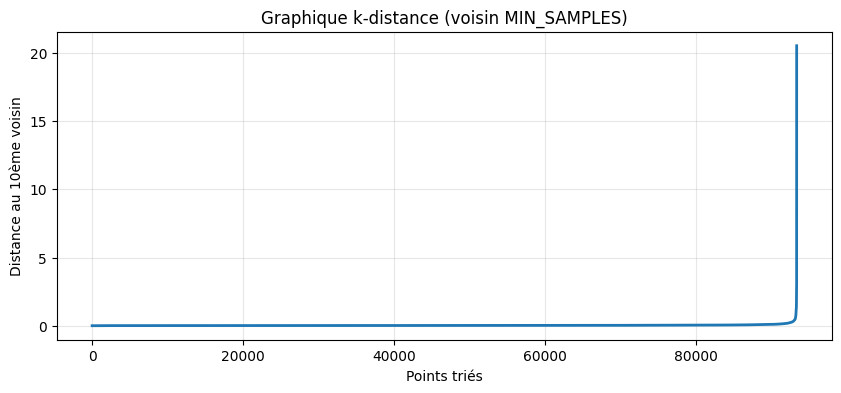

epsilon choisi (P80) = 0.034

→ 292 clusters, 12,806 points de bruit (13.7%), silhouette=-0.361

Distribution des clusters :
cluster_dbscan
-1      12806
 0         13
 1         15
 2         20
 3         23
        ...  
 287        8
 288       14
 289       11
 290       13
 291       12
Name: count, Length: 293, dtype: int64

PROFIL DES CLUSTERS DBSCAN (hors bruit)
                n_clients  R_median  F_median  M_median    CA_total
cluster_dbscan                                                     
45                  73142     254.0       1.0    101.73  9077759.92
90                   2167      39.0       1.0    114.77   259869.64
17                    180     278.0       1.0    621.35   113237.51
25                    101     176.0       1.0    567.00    57837.09
13                     46     228.0       1.0    685.70    31627.99
...                   ...       ...       ...       ...         ...
289                    11     127.0       1.0     22.36      245.62
277           

In [18]:
# DBSCAN

print("\n" + "=" * 70)
print("DBSCAN")
print("=" * 70)

# 1) Paramètres de base
MIN_SAMPLES = 10  # bon départ pour 3 features R/F/M

# 2) k-distance correcte (on inclut soi-même + MIN_SAMPLES voisins)
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES + 1, metric="euclidean").fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
# distance au MIN_SAMPLES-ième voisin effectif
k_distances = np.sort(distances[:, -1])

# 3) Visualisation pour voir le coude grossièrement
plt.figure(figsize=(10, 4))
plt.plot(k_distances, linewidth=2)
plt.title('Graphique k-distance (voisin MIN_SAMPLES)')
plt.xlabel('Points triés')
plt.ylabel(f'Distance au {MIN_SAMPLES}ème voisin')
plt.grid(True, alpha=0.3)
plt.show()

# 4) Choix d'epsilon simple: percentile 80 (souvent raisonnable)
eps = float(np.percentile(k_distances, 80))
print(f"epsilon choisi (P80) = {eps:.3f}")

# 5) Appliquer DBSCAN
model = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
df_rfm['cluster_dbscan'] = model.fit_predict(X_scaled)

# 6) Résumé rapide
n_clusters = len(set(df_rfm['cluster_dbscan'])) - (1 if -1 in df_rfm['cluster_dbscan'].values else 0)
n_noise = int((df_rfm['cluster_dbscan'] == -1).sum())
pct_noise = n_noise / len(df_rfm) * 100

# Silhouette hors bruit (si possible)
mask_no_noise = df_rfm['cluster_dbscan'] != -1
if mask_no_noise.sum() > 0 and n_clusters > 1:
    sil = silhouette_score(X_scaled[mask_no_noise], df_rfm.loc[mask_no_noise, 'cluster_dbscan'])
    sil_str = f"{sil:.3f}"
else:
    sil_str = "N/A"

print(f"\n→ {n_clusters} clusters, {n_noise:,} points de bruit ({pct_noise:.1f}%), silhouette={sil_str}")
print("\nDistribution des clusters :")
print(df_rfm['cluster_dbscan'].value_counts().sort_index())

# 7) Petit profil (hors bruit)
if mask_no_noise.sum() > 0 and n_clusters > 0:
    # si recency/frequency/monetary existent, on les utilise, sinon R/F/M
    if {'recency', 'frequency', 'monetary'}.issubset(df_rfm.columns):
        profile = df_rfm[mask_no_noise].groupby('cluster_dbscan').agg({
            'customer_unique_id': 'count',
            'recency': 'median',
            'frequency': 'median',
            'monetary': ['median', 'sum']
        }).round(2)
        profile.columns = ['n_clients', 'R_median', 'F_median', 'M_median', 'CA_total']
    else:
        profile = df_rfm[mask_no_noise].groupby('cluster_dbscan').agg({
            'R': 'median',
            'F': 'median',
            'M': ['median', 'sum']
        }).round(2)
        profile.columns = ['R_median', 'F_median', 'M_median', 'CA_total']
        profile['n_clients'] = df_rfm[mask_no_noise].groupby('cluster_dbscan').size()
    profile = profile.sort_values('CA_total', ascending=False)

    print("\n" + "=" * 70)
    print("PROFIL DES CLUSTERS DBSCAN (hors bruit)")
    print("=" * 70)
    print(profile)


<>:60: SyntaxWarning: invalid escape sequence '\P'
<>:60: SyntaxWarning: invalid escape sequence '\P'
C:\Users\lza\AppData\Local\Temp\ipykernel_22468\3965545940.py:60: SyntaxWarning: invalid escape sequence '\P'
  print(f"\Points de bruit exclus : {n_noise:,} clients ({pct_noise:.1f}%)")



COMPARAISON K-MEANS vs DBSCAN

 MÉTRIQUES GLOBALES
----------------------------------------------------------------------
Méthode         N Clusters   % Bruit      Silhouette  
----------------------------------------------------------------------
K-Means         4            0%           0.395
DBSCAN          292          13.7%        -0.361
----------------------------------------------------------------------

 PROFILS DES CLUSTERS - K-MEANS
----------------------------------------------------------------------
                n_clients  R_median  F_median  M_median    CA_total
cluster_kmeans                                                     
0                   32201     254.0       1.0    199.27  9519670.09
1                   42323     269.0       1.0     65.84  2885451.75
2                   16033      37.0       1.0    103.89  2150464.45
3                    2801     199.0       2.0    225.55   864187.46

 PROFILS DES CLUSTERS - DBSCAN (hors bruit)
--------------------------

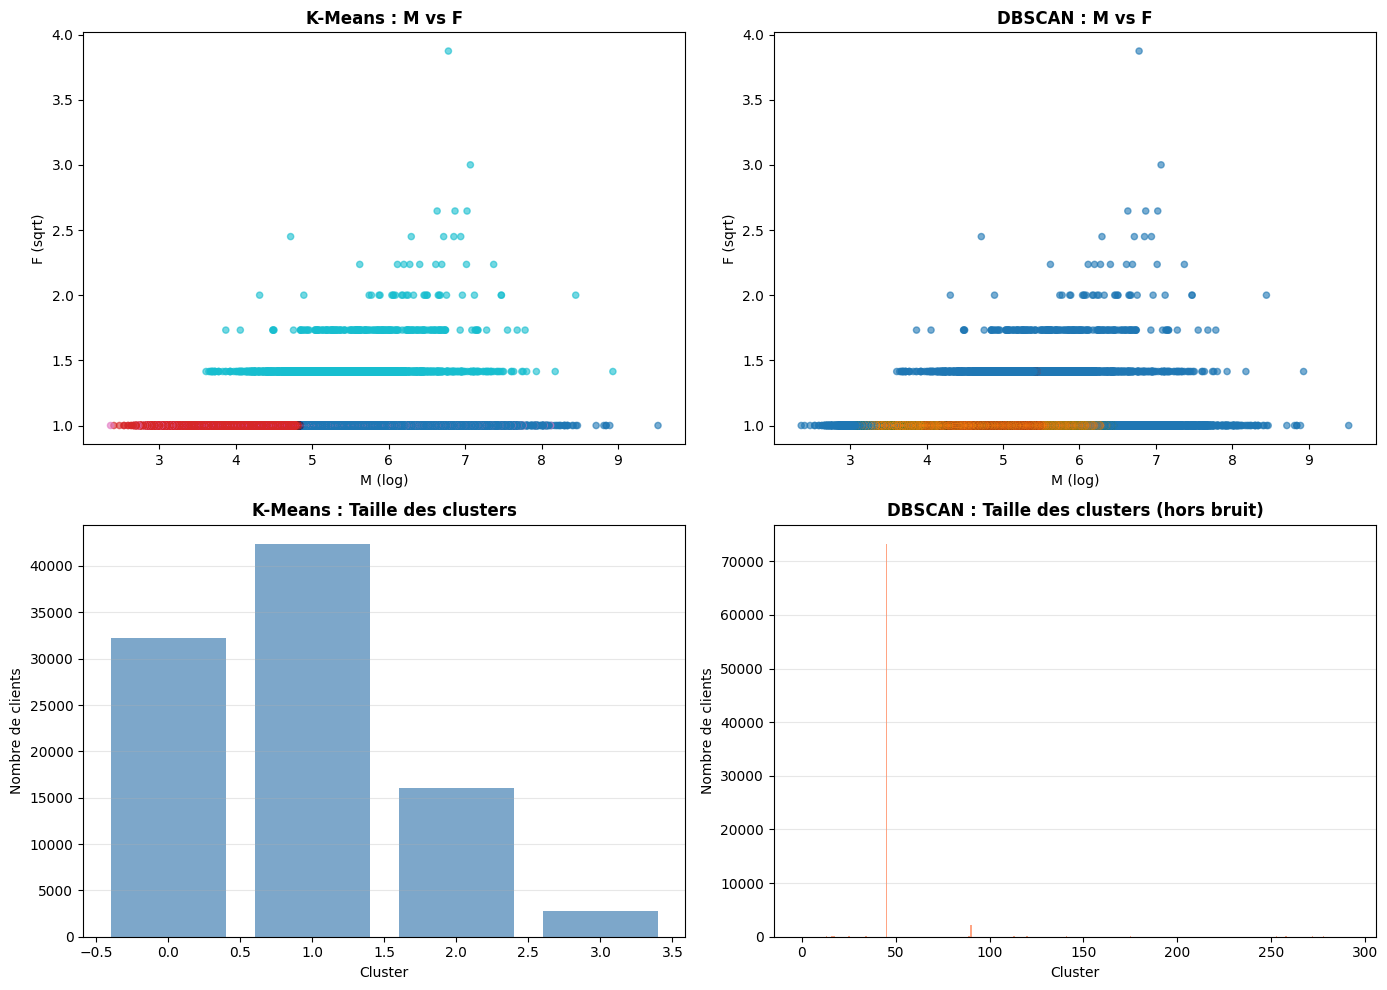


 RECOMMANDATION
 K-MEANS recommandé
  - Meilleure silhouette (0.395 vs -0.361)
  - 4 clusters équilibrés
  - Tous les clients assignés

→ Colonne 'cluster_final' créée avec K-Means


In [20]:
# ===================================
# COMPARAISON K-MEANS vs DBSCAN
# ===================================
print("\n" + "=" * 70)
print("COMPARAISON K-MEANS vs DBSCAN")
print("=" * 70)

# Calcul des métriques comparatives
# Silhouette K-Means
sil_kmeans = silhouette_score(X_scaled, df_rfm['cluster_kmeans'])

# Silhouette DBSCAN (hors bruit)
mask_no_noise = df_rfm['cluster_dbscan'] != -1
n_clusters_db = len(df_rfm[mask_no_noise]['cluster_dbscan'].unique())

if n_clusters_db > 1:
    sil_dbscan = silhouette_score(X_scaled[mask_no_noise], 
                                  df_rfm.loc[mask_no_noise, 'cluster_dbscan'])
else:
    sil_dbscan = np.nan

# Résumé des métriques
print("\n MÉTRIQUES GLOBALES")
print("-" * 70)
print(f"{'Méthode':<15} {'N Clusters':<12} {'% Bruit':<12} {'Silhouette':<12}")
print("-" * 70)
print(f"{'K-Means':<15} {BEST_K:<12} {'0%':<12} {sil_kmeans:.3f}")

n_noise = (df_rfm['cluster_dbscan'] == -1).sum()
pct_noise = n_noise / len(df_rfm) * 100
sil_db_str = f"{sil_dbscan:.3f}" if not np.isnan(sil_dbscan) else "N/A"
print(f"{'DBSCAN':<15} {n_clusters_db:<12} {f'{pct_noise:.1f}%':<12} {sil_db_str}")
print("-" * 70)

# Profils détaillés
print("\n PROFILS DES CLUSTERS - K-MEANS")
print("-" * 70)
profile_km = df_rfm.groupby('cluster_kmeans').agg({
    'customer_unique_id': 'count',
    'recency': 'median',
    'frequency': 'median',
    'monetary': ['median', 'sum']
}).round(2)
profile_km.columns = ['n_clients', 'R_median', 'F_median', 'M_median', 'CA_total']
profile_km = profile_km.sort_values('CA_total', ascending=False)
print(profile_km)

if n_clusters_db > 0:
    print("\n PROFILS DES CLUSTERS - DBSCAN (hors bruit)")
    print("-" * 70)
    profile_db = df_rfm[mask_no_noise].groupby('cluster_dbscan').agg({
        'customer_unique_id': 'count',
        'recency': 'median',
        'frequency': 'median',
        'monetary': ['median', 'sum']
    }).round(2)
    profile_db.columns = ['n_clients', 'R_median', 'F_median', 'M_median', 'CA_total']
    profile_db = profile_db.sort_values('CA_total', ascending=False)
    print(profile_db)
    print(f"\Points de bruit exclus : {n_noise:,} clients ({pct_noise:.1f}%)")

# Visualisation comparative
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plots

axes[0, 0].scatter(M_transformed, F_transformed, 
                   c=df_rfm['cluster_kmeans'], cmap='tab10', alpha=0.6, s=20)
axes[0, 0].set_xlabel('M (log)')
axes[0, 0].set_ylabel('F (sqrt)')
axes[0, 0].set_title('K-Means : M vs F', fontweight='bold')

axes[0, 1].scatter(M_transformed, F_transformed, 
                   c=df_rfm['cluster_dbscan'], cmap='tab10', alpha=0.6, s=20)
axes[0, 1].set_xlabel('M (log)')
axes[0, 1].set_ylabel('F (sqrt)')
axes[0, 1].set_title('DBSCAN : M vs F', fontweight='bold')

# Bar charts
axes[1, 0].bar(profile_km.index, profile_km['n_clients'], color='steelblue', alpha=0.7)
axes[1, 0].set_title('K-Means : Taille des clusters', fontweight='bold')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Nombre de clients')
axes[1, 0].grid(True, alpha=0.3, axis='y')

if n_clusters_db > 0:
    axes[1, 1].bar(profile_db.index, profile_db['n_clients'], color='coral', alpha=0.7)
    axes[1, 1].set_title('DBSCAN : Taille des clusters (hors bruit)', fontweight='bold')
else:
    axes[1, 1].text(0.5, 0.5, 'DBSCAN : Segmentation non exploitable', 
                    ha='center', va='center', fontsize=12)
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Nombre de clients')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Décision automatique
print("\n" + "=" * 70)
print(" RECOMMANDATION")
print("=" * 70)

# Critères de décision
kmeans_ok = True  # K-Means fonctionne toujours
dbscan_ok = (n_clusters_db >= 3 and pct_noise < 20 and not np.isnan(sil_dbscan))

if dbscan_ok and sil_dbscan > sil_kmeans:
    print(" DBSCAN recommandé")
    print(f"  - Meilleure silhouette ({sil_dbscan:.3f} vs {sil_kmeans:.3f})")
    print(f"  - Détecte {pct_noise:.1f}% d'outliers")
    print(f"  - {n_clusters_db} clusters exploitables")
    df_rfm['cluster_final'] = df_rfm['cluster_dbscan']
    CHOSEN_METHOD = 'DBSCAN'
else:
    print(" K-MEANS recommandé")
    if not dbscan_ok:
        if n_clusters_db < 3:
            print(f"  - DBSCAN : trop peu de clusters ({n_clusters_db})")
        if pct_noise >= 20:
            print(f"  - DBSCAN : trop de bruit ({pct_noise:.1f}%)")
    else:
        print(f"  - Meilleure silhouette ({sil_kmeans:.3f} vs {sil_dbscan:.3f})")
    print(f"  - {BEST_K} clusters équilibrés")
    print("  - Tous les clients assignés")
    df_rfm['cluster_final'] = df_rfm['cluster_kmeans']
    CHOSEN_METHOD = 'K-Means'

print(f"\n→ Colonne 'cluster_final' créée avec {CHOSEN_METHOD}")

In [ ]:
print("\n" + "=" * 70)
print(" MODÈLE RETENU : K-MEANS")
print("=" * 70)

# Garder uniquement K-Means
df_rfm['cluster_final'] = df_rfm['cluster_kmeans']

print(f" {BEST_K} segments créés")
print(f" Silhouette score : {sil_kmeans:.3f}")
print("\n Distribution des segments :")
print(df_rfm['cluster_final'].value_counts().sort_index())

# Profil détaillé final
profile_final = df_rfm.groupby('cluster_final').agg({
    'customer_unique_id': 'count',
    'recency': ['mean', 'median'],
    'frequency': ['mean', 'median'],
    'monetary': ['mean', 'median', 'sum']
}).round(2)

profile_final.columns = ['n_clients', 'R_mean', 'R_median', 
                         'F_mean', 'F_median', 'M_mean', 'M_median', 'CA_total']
profile_final = profile_final.sort_values('CA_total', ascending=False)

print("\n" + "=" * 70)
print("PROFIL DES SEGMENTS")
print("=" * 70)
print(profile_final)





🏆 MODÈLE RETENU : K-MEANS
✓ 4 segments créés
✓ Silhouette score : 0.350

Distribution des segments :
cluster_final
0    30827
1    12597
2    16019
3    37035
Name: count, dtype: int64

PROFIL DES SEGMENTS
               n_clients  R_mean  R_median  F_mean  F_median  M_mean  \
cluster_final                                                          
1                  12597  242.39     216.0     1.0       1.0  519.59   
3                  37035  289.93     271.0     1.0       1.0  142.52   
2                  16019   39.96      36.0     1.0       1.0  123.95   
0                  30827  280.24     264.0     1.0       1.0   52.25   

               M_median    CA_total  
cluster_final                        
1                371.32  6545239.81  
3                134.47  5278331.47  
2                101.78  1985524.77  
0                 52.53  1610677.70  


In [ ]:
# Create the missing Bar Chart for total revenue (CA_total) per cluster

# NOTE: The DataFrame 'profile_final' is available from the last successful execution (Cell 57)
# It is already sorted by 'CA_total' descending, which is perfect for plotting.

import matplotlib.pyplot as plt

# Ensure the plot is clean and informative
plt.figure(figsize=(8, 6))
profile_final['CA_total'].plot(kind='bar', color='darkgreen', alpha=0.8)

plt.title('Chiffre d\'Affaires Total par Segment (K-Means)', fontweight='bold')
plt.xlabel('Segment Client (Cluster)')
plt.ylabel('Chiffre d\'Affaires Total (€)')
plt.xticks(rotation=0) # Keep labels horizontal
plt.grid(True, axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('CA_cluster_barchart.png')

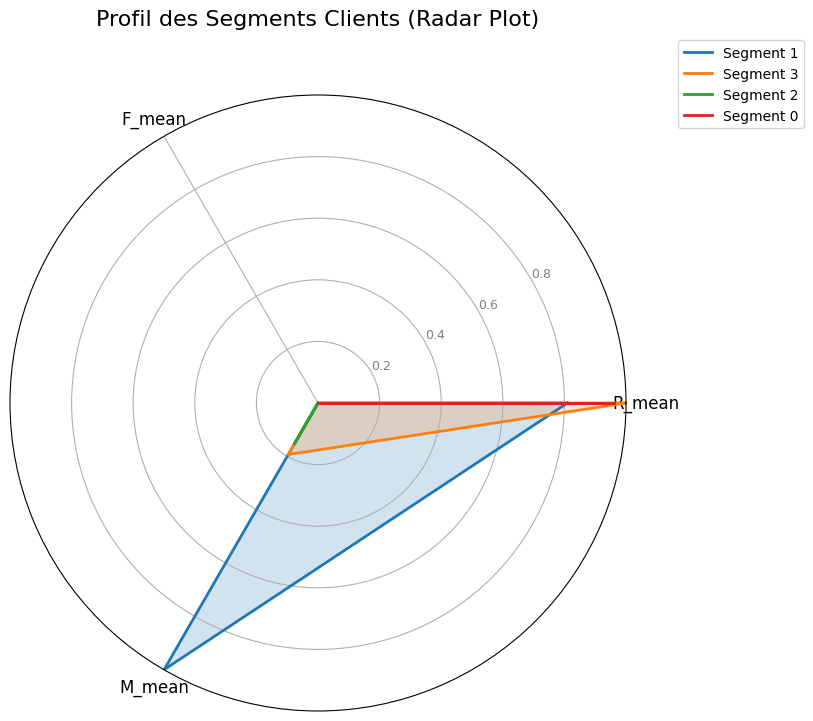

In [ ]:


# --- 1. Préparation des données ---

# On sélectionne les colonnes moyennes qui nous intéressent pour la visualisation
profile_for_plot = profile_final[['R_mean', 'F_mean', 'M_mean']].copy()

# On inverse la Récence pour que "plus haut" signifie "mieux" (plus récent)
# C'est une option qui peut rendre le graphique plus intuitif.



# Utilisation du MinMaxScaler pour ramener toutes les valeurs entre 0 et 1
scaler = MinMaxScaler()
profile_scaled = pd.DataFrame(scaler.fit_transform(profile_for_plot), 
                              columns=profile_for_plot.columns, 
                              index=profile_for_plot.index)

# --- 2. Création du Radar Plot ---

# Variables pour le graphique
labels = profile_scaled.columns
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Répéter le premier angle à la fin pour fermer le polygone

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Boucle pour tracer chaque segment
for i, row in profile_scaled.iterrows():
    values = row.tolist()
    values += values[:1] # Répéter la première valeur pour fermer le polygone
    ax.plot(angles, values, label=f'Segment {i}', linewidth=2)
    ax.fill(angles, values, alpha=0.2)

# --- 3. Amélioration de l'esthétique ---

# Ajout des labels pour chaque axe
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=12)

# Ajustement de l'axe y (les cercles concentriques)
ax.set_rlabel_position(30)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="grey", size=9)
plt.ylim(0, 1)

# Titre et légende
plt.title('Profil des Segments Clients (Radar Plot)', size=16, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

# Comprendre et analyser les profils type clients actuels

                n_clients  R_median  F_median  M_median    CA_total
cluster_kmeans                                                     
1                   12597     216.0       1.0    371.32  6545239.81
3                   37035     271.0       1.0    134.47  5278331.47
2                   16019      36.0       1.0    101.78  1985524.77
0                   30827     264.0       1.0     52.53  1610677.70


In [ ]:
DB_PATH = Path(r"C:\Users\lza\Documents\P04_Segmenter_Clients_E-Commerce\olist.db")

# Vérifier si le fichier existe pour éviter une erreur
if not DB_PATH.exists():
    raise FileNotFoundError(f"Fichier de base de données introuvable : {DB_PATH}")

# Établir la connexion
try:
    conn = sqlite3.connect(DB_PATH)
    print("Connexion à la base de données Olist réussie.")
except sqlite3.Error as e:
    print(f"Erreur de connexion : {e}")
    # Fonctions utilitaires
def run_query(conn, sql):
    df = pd.read_sql_query(sql, conn)
    return df

# On repart de la première requête SQL

sql_client_file = """
WITH delivered AS (
  SELECT o.order_id, o.customer_id, c.customer_unique_id, DATE(o.order_purchase_timestamp) AS purchase_ts
  FROM orders o JOIN customers c ON o.customer_id = c.customer_id
  WHERE o.order_status = 'delivered'
),
per_order_value AS (
  SELECT d.order_id, SUM(oi.price + oi.freight_value) AS order_value
  FROM delivered d JOIN order_items oi ON oi.order_id = d.order_id
  GROUP BY d.order_id
),
rfm_base AS (
  SELECT
    d.customer_unique_id,
    MAX(d.purchase_ts) AS last_order_date,
    COUNT(DISTINCT d.order_id) AS n_orders,
    SUM(pov.order_value) AS m_amount_total
  FROM delivered d JOIN per_order_value pov ON pov.order_id = d.order_id
  GROUP BY d.customer_unique_id
),
review_mean AS (
  SELECT d.customer_unique_id, AVG(CAST(rw.review_score AS REAL)) AS review_score_mean
  FROM order_reviews rw JOIN delivered d ON d.order_id = rw.order_id
  GROUP BY d.customer_unique_id
)
SELECT
  r.customer_unique_id,
  CAST(JULIANDAY((SELECT MAX(purchase_ts) FROM delivered)) - JULIANDAY(r.last_order_date) AS INTEGER) AS days_since_last_order, -- R
  r.n_orders, -- F
  r.m_amount_total, -- M
  rm.review_score_mean -- La feature supplémentaire !
FROM rfm_base r
LEFT JOIN review_mean rm ON rm.customer_unique_id = r.customer_unique_id;
"""

df_clients = pd.read_sql_query(sql_client_file, conn)

# On renomme les colonnes pour correspondre à votre script

df_rfm = df_clients.rename(columns={
    'days_since_last_order': 'R',
    'n_orders': 'F',
    'm_amount_total': 'M',
    'review_score_mean': 'review_score' 
})

#  Gestion des valeurs manquantes pour 'review_score'

# Remplir les NaN avec la médiane des scores existants.
review_median = df_rfm['review_score'].median()
df_rfm['review_score'] = df_rfm['review_score'].fillna(review_median)
print(f"Les valeurs manquantes de 'review_score' ont été remplacées par la médiane : {review_median:.2f}\n")

# le DataFrame `df_rfm` est prêt !
print("Aperçu du DataFrame prêt pour le clustering :")
print(df_rfm.head())
print(f"\nDimensions du DataFrame: {df_rfm.shape}")
print("\nInfos sur les colonnes :")
df_rfm.info()

Connexion à la base de données Olist réussie.
Les valeurs manquantes de 'review_score' ont été remplacées par la médiane : 5.00

Aperçu du DataFrame prêt pour le clustering :
                 customer_unique_id    R  F       M  review_score
0  0000366f3b9a7992bf8c76cfdf3221e2  111  1  141.90           5.0
1  0000b849f77a49e4a4ce2b2a4ca5be3f  114  1   27.19           4.0
2  0000f46a3911fa3c0805444483337064  537  1   86.22           3.0
3  0000f6ccb0745a6a4b88665a16c9f078  321  1   43.62           4.0
4  0004aac84e0df4da2b147fca70cf8255  288  1  196.89           5.0

Dimensions du DataFrame: (93358, 5)

Infos sur les colonnes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93358 entries, 0 to 93357
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  93358 non-null  object 
 1   R                   93358 non-null  int64  
 2   F                   93358 non-null  int64  
 3   M       

In [ ]:

# ANALYSE K-MEANS AVEC FEATURE SUPPLÉMENTAIRE

print("\n" + "=" * 70)
print("TEST AVEC UNE FEATURE SUPPLÉMENTAIRE")
print("=" * 70)

# Vérifier les colonnes disponibles
print("\nColonnes disponibles dans df_rfm :")
print(df_rfm.columns.tolist())

# Ajouter les features si disponibles
additional_features = []
if 'review_score' in df_rfm.columns:
    additional_features.append('review_score')
    print("\n✓ 'review_score' trouvé et prêt à être utilisé.")
else:
    print("\n 'review_score' n'a pas été trouvé. Vérifiez l'étape de préparation.")

if len(additional_features) > 0:
    print(f"→ Features supplémentaires à tester : {additional_features}")
    
    # Préparer les données avec features supplémentaires
    features_extended = ['R', 'F', 'M'] + additional_features
    df_rfm_extended = df_rfm[features_extended].copy()
    
    # Transformations 
    R_ext = np.log1p(df_rfm_extended['R'])
    F_ext = np.sqrt(df_rfm_extended['F'])
    M_ext = np.log1p(df_rfm_extended['M'])
    
    # Pas besoin de transformer le score de review (déjà sur une échelle de 1 à 5)
    review_score_transformed = df_rfm_extended['review_score'].values
    
    # Créer la matrice étendue
    X_extended = np.column_stack([R_ext, F_ext, M_ext, review_score_transformed])
    
    # Standardiser
    scaler_ext = StandardScaler()
    X_scaled_extended = scaler_ext.fit_transform(X_extended)
    
    print(f"\nMatrice étendue : {X_scaled_extended.shape[1]} features (vs 3 avant)")
    
  
    # K-Means avec features étendues
  
    print("\n" + "=" * 70)
    print(f"K-MEANS AVEC FEATURES ÉTENDUES ({', '.join(features_extended)})")
    print("=" * 70)
    
    silhouette_scores_ext = []
    k_range = range(2, 9)
    
    print("\nTest de différents k :")
    for k in k_range:
        km_ext = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels_ext = km_ext.fit_predict(X_scaled_extended)
        sil_ext = silhouette_score(X_scaled_extended, labels_ext)
        silhouette_scores_ext.append(sil_ext)
        print(f"k={k} → silhouette={sil_ext:.3f}")
    
    # Choisir le meilleur k
    best_k_ext = k_range[np.argmax(silhouette_scores_ext)]
    best_sil_ext = max(silhouette_scores_ext)
    
    print(f"\n✓ Meilleur k avec features étendues : {best_k_ext} (silhouette={best_sil_ext:.3f})")
    
    # Appliquer le K-Means final
    kmeans_extended = KMeans(n_clusters=best_k_ext, random_state=42, n_init=10)
    df_rfm_extended['cluster_extended'] = kmeans_extended.fit_predict(X_scaled_extended)
    
    # Profiling (votre code est déjà bon)
    agg_dict = {'R': 'median', 'F': 'median', 'M': ['median', 'sum'], 'review_score': 'median'}
    profile_ext = df_rfm_extended.groupby('cluster_extended').agg(agg_dict).round(2)
    profile_ext.columns = ['R_med', 'F_med', 'M_med', 'CA_total', 'review_score_med']
    profile_ext['n_clients'] = df_rfm_extended.groupby('cluster_extended').size()
    profile_ext = profile_ext.sort_values('CA_total', ascending=False)
    
    print("\n" + "=" * 70)
    print("PROFIL DES CLUSTERS AVEC FEATURES ÉTENDUES")
    print("=" * 70)
    print(profile_ext)

else:
    print("Aucune feature supplémentaire n'a été ajoutée. Le script s'arrête.")


TEST AVEC UNE FEATURE SUPPLÉMENTAIRE

Colonnes disponibles dans df_rfm :
['customer_unique_id', 'R', 'F', 'M', 'review_score']

✓ 'review_score' trouvé et prêt à être utilisé.
→ Features supplémentaires à tester : ['review_score']

Matrice étendue : 4 features (vs 3 avant)

K-MEANS AVEC FEATURES ÉTENDUES (R, F, M, review_score)

Test de différents k :
k=2 → silhouette=0.644
k=3 → silhouette=0.371
k=4 → silhouette=0.369
k=5 → silhouette=0.339
k=6 → silhouette=0.303
k=7 → silhouette=0.294
k=8 → silhouette=0.287

✓ Meilleur k avec features étendues : 2 (silhouette=0.644)

PROFIL DES CLUSTERS AVEC FEATURES ÉTENDUES
                  R_med  F_med   M_med     CA_total  review_score_med  \
cluster_extended                                                        
0                 219.0    1.0  105.38  14555586.29              5.00   
1                 199.0    2.0  225.55    864187.46              4.67   

                  n_clients  
cluster_extended             
0                     90557

In [ ]:
# 1. Créer un dictionnaire de correspondance (mapping)
# La clé est le numéro du cluster, la valeur est le nouveau nom que vous lui donnez.
segment_map = {
    1: 'Clients à Risque',
    2: 'Nouveaux Clients',
    3: 'Clients Dormants',
    0: 'Clients Perdus'
}

# 2. Appliquer ce mapping pour créer une nouvelle colonne
# C'est une bonne pratique de créer une nouvelle colonne pour garder l'originale
df_rfm['segment_nom'] = df_rfm['cluster_final'].map(segment_map)

# 3. Vérifier le résultat
print("Les segments ont été renommés :")
print(df_rfm['segment_nom'].value_counts())

print("\nAperçu du DataFrame avec la nouvelle colonne :")
print(df_rfm[['customer_unique_id', 'recency', 'frequency', 'monetary', 'cluster_final', 'segment_nom']].head())

Les segments ont bien été renommés :
segment_nom
Clients Dormants    37035
Clients Perdus      30827
Nouveaux Clients    16019
Clients à Risque    12597
Name: count, dtype: int64

Aperçu du DataFrame avec la nouvelle colonne :
                        customer_id  recency  frequency  monetary  \
0  1617b1357756262bfa56ab541c47bc16      333          1  13664.08   
1  ec5b2ba62e574342386871631fafd3fc       45          1   7274.88   
2  c6e2731c5b391845f6800c97401a43a9      562          1   6929.31   
3  f48d464a0baaea338cb25f816991ab1f       34          1   6922.21   
4  3fd6777bbce08a352fddd04e4a7cc8f6      461          1   6726.66   

   cluster_final       segment_nom  
0              1  Clients à Risque  
1              1  Clients à Risque  
2              1  Clients à Risque  
3              1  Clients à Risque  
4              1  Clients à Risque  


# Vue finale

C:\Users\lza\AppData\Local\Temp\ipykernel_20660\635808950.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f} €'.format(x).replace(',', ' ') for x in y_ticks])


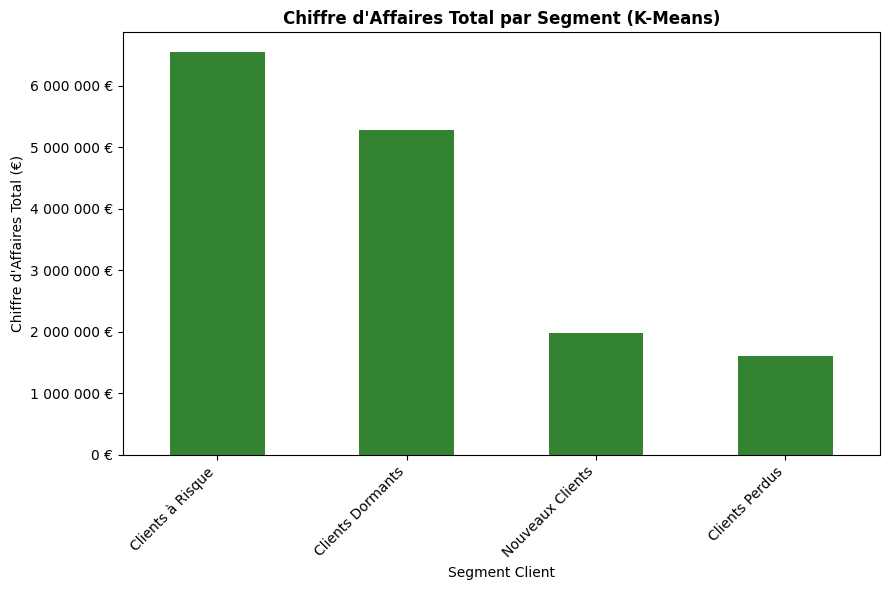

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Définition du mapping fourni par l'utilisateur
segment_map = {
    1: 'Clients à Risque',
    2: 'Nouveaux Clients',
    3: 'Clients Dormants',
    0: 'Clients Perdus'
}

# 2. Reconstruction du DataFrame de profil (classé par CA décroissant)
# Les index numériques [1, 3, 2, 0] correspondent à l'ordre du CA
data = {
    'CA_total': [6545239.81, 5278331.47, 1985524.77, 1610677.70]
}
numerical_index = pd.Index([1, 3, 2, 0], name='cluster_final')
profile_final = pd.DataFrame(data, index=numerical_index)

# 3. Application des noms aux étiquettes (index)
profile_final.index = profile_final.index.map(segment_map)
profile_final.index.name = 'Segment Client'

# 4. Création du graphique avec les noms de segments
plt.figure(figsize=(9, 6))
profile_final['CA_total'].plot(kind='bar', color='darkgreen', alpha=0.8)

plt.title('Chiffre d\'Affaires Total par Segment (K-Means)', fontweight='bold')
plt.xlabel('Segment Client')
plt.ylabel('Chiffre d\'Affaires Total (€)')

# Rotation à 45 degrés
plt.xticks(rotation=45, ha='right')

# Formatage de l'axe Y pour la lisibilité en euros
y_ticks = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f} €'.format(x).replace(',', ' ') for x in y_ticks])

plt.tight_layout()
plt.show()

In [24]:
print(f"Nombre de lignes dans df_rfm: {df_rfm.shape[0]}")
print(f"Aperçu des 5 premières lignes :")
print(df_rfm.head())

# Reconstitution du mapping pour le nommage (à ré-exécuter si le mapping a été perdu)
segment_map = {
    1: 'Clients à Risque',
    2: 'Nouveaux Clients',
    3: 'Clients Dormants',
    0: 'Clients Perdus'
}
ID_COL = 'customer_unique_id'
cols = [ID_COL, 'recency', 'frequency', 'monetary', 'cluster_final', 'segment_nom']
missing = [c for c in cols if c not in df_rfm.columns]
if missing:
    raise KeyError(f"Colonnes manquantes: {missing}")
df_rfm['segment_nom'] = df_rfm['cluster_final'].map(segment_map)
df_rfm_scored = df_rfm[cols].copy()
df_rfm_scored.to_csv('customers_rfm_scored.csv', index=False)
print(f"Export réussi : customers_rfm_scored.csv avec {ID_COL}.")

Nombre de lignes dans df_rfm: 93358
Aperçu des 5 premières lignes :
                 customer_unique_id  recency  frequency  monetary  \
0  0a0a92112bd4c708ca5fde585afaa872      334          1  13664.08   
1  da122df9eeddfedc1dc1f5349a1a690c      515          2   7571.63   
2  763c8b1c9c68a0229c42c9fc6f662b93       45          1   7274.88   
3  dc4802a71eae9be1dd28f5d788ceb526      563          1   6929.31   
4  459bef486812aa25204be022145caa62       35          1   6922.21   

   cluster_kmeans  cluster_dbscan  cluster_final       segment_nom  
0               0              -1              0    Clients Perdus  
1               3              -1              3  Clients Dormants  
2               0              -1              0    Clients Perdus  
3               0              -1              0    Clients Perdus  
4               0              -1              0    Clients Perdus  
Export réussi : customers_rfm_scored.csv avec customer_unique_id.
